# 🎯 Hand Gesture Classification — Notebook 4: Model Evaluation (Test Set)

### **🎯 Mục tiêu chính của Notebook này:**

1.  **Mở khóa Tập Test (Unseen Data):** Lấy 20% dữ liệu đã được bảo lập từ ban đầu ra để kiểm chứng.
2.  **Đánh giá XGBoost (Cử chỉ tĩnh):** * Chạy mô hình tốt nhất (`gesture_model_tuned.pkl`).
    * Trích xuất `Classification Report`, `Confusion Matrix` và `Feature Importances`.
3.  **Đánh giá GRU (Cử chỉ động):** * Chạy mạng nơ-ron tốt nhất (`motion_model.pth`).
    * Trích xuất các chỉ số tương tự cho dữ liệu chuỗi thời gian.
4.  **Xuất Dữ liệu cho Power BI:** Tự động lưu các kết quả đánh giá ra file `.csv` để phục vụ vẽ Dashboard Hệ thống.

In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from motion_detection.handlers.gru import MotionGRU
from motion_detection.utils.plot import plot_composite_evaluation

%matplotlib inline

# --- ⚙️ THIẾT LẬP MÔI TRƯỜNG & ĐỌC DỮ LIỆU TĨNH ---
CURRENT_DIR = os.getcwd()
MODELS_DIR = os.path.join(CURRENT_DIR, 'motion_detection','models')
DIR = os.path.join(CURRENT_DIR, 'motion_detection')
OUT_FIG = 'Images'
OUT_TBL = 'Tables'
CSV_PATH = os.path.join(MODELS_DIR, 'hand_gestures.csv')

print("1. Đọc dữ liệu tĩnh từ:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
X = df.drop('label', axis=1) 
y = df['label']              

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Tái tạo ĐÚNG tập Test 20% như ở Notebook 3 (Nhờ chung random_state=42)
_, X_test_static, _, y_test_static = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"Số mẫu Test Cử chỉ tĩnh (XGBoost): {len(X_test_static)}")

1. Đọc dữ liệu tĩnh từ: d:\Hand_Gesture_Recognition\motion_detection\models\hand_gestures.csv
Số mẫu Test Cử chỉ tĩnh (XGBoost): 2894


## 🌲 1. Đánh giá Mô hình XGBoost (Cử chỉ tĩnh)

Đọc file `.pkl` đã được tuning ở Notebook trước và chạy dự đoán. Chúng ta sẽ xuất thẳng kết quả ra file để Power BI có thể đọc được.

In [2]:
print("--- ĐÁNH GIÁ XGBOOST TRÊN TẬP TEST ---")

# 1. Load Model Tốt nhất
xgb_model_path = os.path.join(MODELS_DIR, 'gesture_model_tuned.pkl')
with open(xgb_model_path, 'rb') as f:
    best_xgb = pickle.load(f)

# 2. Dự đoán
y_pred_static = best_xgb.predict(X_test_static)
test_acc_xgb = accuracy_score(y_test_static, y_pred_static)
print(f"Độ chính xác (Accuracy) trên tập Test: {test_acc_xgb*100:.2f}%\n")

# 3. Xuất Classification Report
target_names = label_encoder.classes_
report_dict = classification_report(y_test_static, y_pred_static, target_names=target_names, output_dict=True)

metrics_data = []
for label, metrics in report_dict.items():
    if label not in ['accuracy', 'macro avg', 'weighted avg']:
        metrics_data.append({
            'Class': label,
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1_Score': metrics['f1-score'],
            'Support': metrics['support']
        })
metrics_data.append({
    'Class': 'Macro Average',
    'Precision': report_dict['macro avg']['precision'],
    'Recall': report_dict['macro avg']['recall'],
    'F1_Score': report_dict['macro avg']['f1-score'],
    'Support': report_dict['macro avg']['support']
})

pd.DataFrame(metrics_data).to_csv(os.path.join(MODELS_DIR, 'powerbi_model_metrics.csv'), index=False)
print("Đã xuất file: powerbi_model_metrics.csv")

# 4. Xuất Confusion Matrix (Melted cho Power BI)
cm = confusion_matrix(y_test_static, y_pred_static, labels=np.arange(len(target_names)))
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
cm_df.index.name = 'True_Label'
cm_df.reset_index(inplace=True)
cm_df_melted = cm_df.melt(id_vars='True_Label', var_name='Predicted_Label', value_name='Count')

pd.DataFrame(cm_df_melted).to_csv(os.path.join(MODELS_DIR, 'powerbi_confusion_matrix.csv'), index=False)
print("Đã xuất file: powerbi_confusion_matrix.csv")

# 5. Xuất Feature Importances
importances = best_xgb.feature_importances_
features = X.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)
feat_imp_df.to_csv(os.path.join(MODELS_DIR, 'powerbi_feature_importance.csv'), index=False)
print("Đã xuất file: powerbi_feature_importance.csv")

--- ĐÁNH GIÁ XGBOOST TRÊN TẬP TEST ---
Độ chính xác (Accuracy) trên tập Test: 91.40%

Đã xuất file: powerbi_model_metrics.csv
Đã xuất file: powerbi_confusion_matrix.csv
Đã xuất file: powerbi_feature_importance.csv


## 🏃‍♂️ 2. Đánh giá Mạng Nơ-ron GRU (Cử chỉ động)

*Ghi chú: Cell này mô phỏng quá trình load file tensor `.npy` và đánh giá GRU. Cấu trúc xuất file cũng được thiết kế chuẩn hóa cho Dashboard Power BI.*

In [3]:
print("\n--- ĐÁNH GIÁ MẠNG GRU TRÊN TẬP TEST ---")

X_test_dyn_path = os.path.join(DIR, 'X_test_dynamic.npy')
y_test_dyn_path = os.path.join(DIR, 'y_test_dynamic.npy')
gru_model_path = os.path.join(MODELS_DIR, 'motion_model.pth')

# 2. LOAD DỮ LIỆU TEST (20% đã lưu từ file train_gru.py)
try:
    X_test_dynamic = np.load(X_test_dyn_path)
    y_test_dynamic = np.load(y_test_dyn_path)
    print(f"Đã tải tập Test Động. Số lượng mẫu: {len(X_test_dynamic)}")
except FileNotFoundError:
    print("LỖI: Chưa tìm thấy file Test.")
    raise

# 3. KHỞI TẠO VÀ LOAD MÔ HÌNH GRU TỐT NHẤT
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sử dụng thiết bị tính toán: {device}")

# Khởi tạo khung mạng (Nhớ để hidden_size=64 cho khớp với file train)
best_gru = MotionGRU(input_size=252, hidden_size=64, num_layers=2, num_classes=3)

# Lắp bộ não (trọng số) vào khung mạng
best_gru.load_state_dict(torch.load(gru_model_path, map_location=device, weights_only=True))
best_gru.to(device)

# Bật chế độ chấm điểm (Tắt tính năng Dropout chống nhiễu)
best_gru.eval() 

# 4. TIỀN XỬ LÝ SHAPE VÀ TẠO DATALOADER (FIX LỖI 1D TẠI ĐÂY)
X_tensor = torch.tensor(X_test_dynamic, dtype=torch.float32)
y_tensor = torch.tensor(y_test_dynamic, dtype=torch.long)

# Ép khuôn dữ liệu về đúng chuẩn 3D: (Batch_Size, 50 frames, 252 features)
try:
    X_tensor = X_tensor.view(-1, 50, 252)
    print(f"Đã ép chuẩn Shape cho GRU thành công: {X_tensor.shape}")
except RuntimeError as e:
    print(f"Lỗi Reshape: Tổng số phần tử không khớp. Có thể data bị lỗi lúc save. Chi tiết: {e}")

# Dùng DataLoader chia lô giống lúc Train để không bị lỗi bộ nhớ
test_dataset = TensorDataset(X_tensor, y_tensor)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 5. TIẾN HÀNH SUY LUẬN (INFERENCE)
y_pred_list = []
y_true_list = []
y_proba_list = [] # Lưu thêm xác suất

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        outputs = best_gru(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        y_pred_list.extend(preds.cpu().numpy())
        y_true_list.extend(labels.numpy())  
        y_proba_list.extend(probs.cpu().numpy())

test_acc_gru = accuracy_score(y_true_list, y_pred_list)
print(f"Độ chính xác (Accuracy) trên tập Test: {test_acc_gru*100:.2f}%\n")


--- ĐÁNH GIÁ MẠNG GRU TRÊN TẬP TEST ---
Đã tải tập Test Động. Số lượng mẫu: 400
Sử dụng thiết bị tính toán: cpu
Đã ép chuẩn Shape cho GRU thành công: torch.Size([400, 50, 252])
Độ chính xác (Accuracy) trên tập Test: 88.75%



--- ĐÁNH GIÁ XGBOOST ---
Độ chính xác XGBoost: 91.40%
📸 Đã lưu biểu đồ kết hợp vào: Images\xgb_test_combined.png


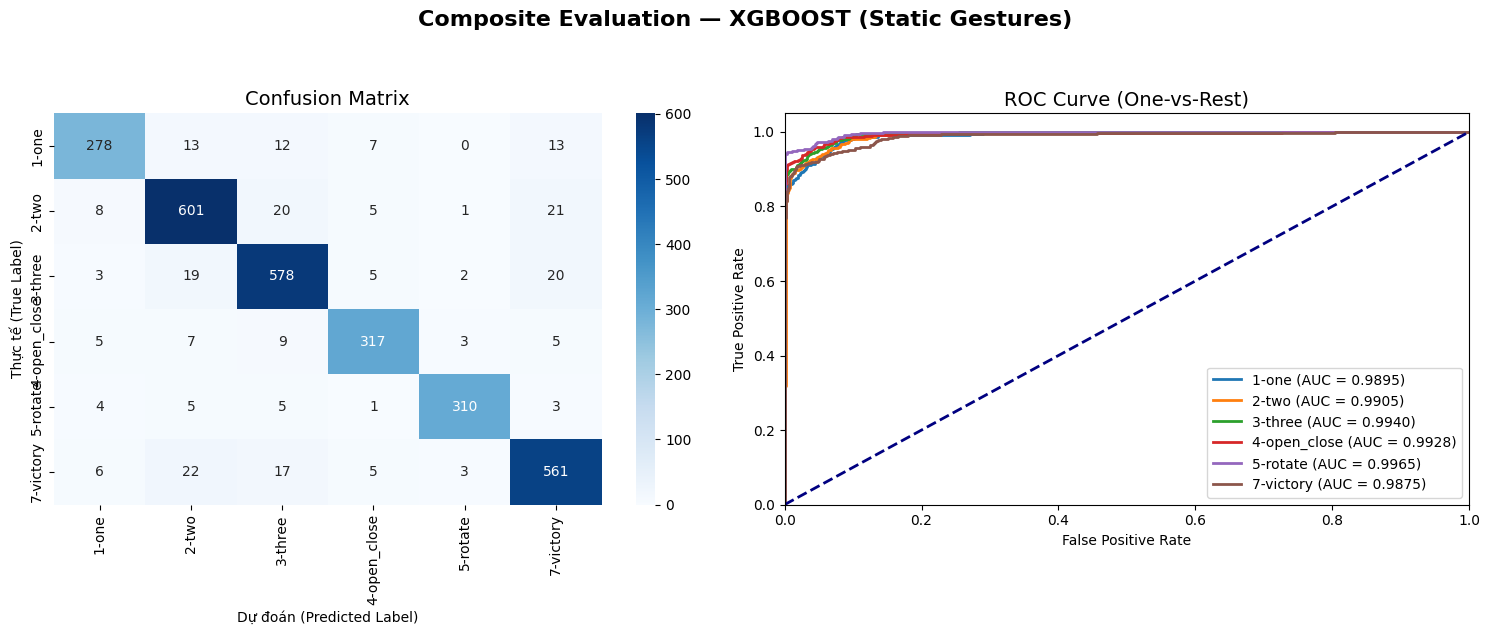

In [4]:
# ==============================================================
# 1. ĐÁNH GIÁ XGBOOST (CỬ CHỈ TĨNH)
# ==============================================================
print("--- ĐÁNH GIÁ XGBOOST ---")
# Giả định bạn đã có X_test_static, y_test_static và target_names_static từ các Cell trước
with open(os.path.join(MODELS_DIR, 'gesture_model_tuned.pkl'), 'rb') as f:
    best_xgb = pickle.load(f)

y_pred_xgb = best_xgb.predict(X_test_static)
y_proba_xgb = best_xgb.predict_proba(X_test_static)

# Tính điểm
test_acc_xgb = accuracy_score(y_test_static, y_pred_static)
f1_xgb = f1_score(y_test_static, y_pred_static, average="macro")
print(f"Độ chính xác XGBoost: {test_acc_xgb*100:.2f}%")

# Vẽ hình
target_names = label_encoder.classes_
plot_composite_evaluation(
    y_test_static, y_pred_xgb, y_proba_xgb, target_names,
    "Composite Evaluation — XGBOOST (Static Gestures)", 
    os.path.join(OUT_FIG, "xgb_test_combined.png")
)




--- ĐÁNH GIÁ GRU ---
Độ chính xác GRU: 88.75%
Macro F1-Score của GRU: 88.75%
Micro F1-Score của GRU: 88.75%
Weighted F1-Score của GRU: 88.75%
📸 Đã lưu biểu đồ kết hợp vào: Images\gru_test_combined.png


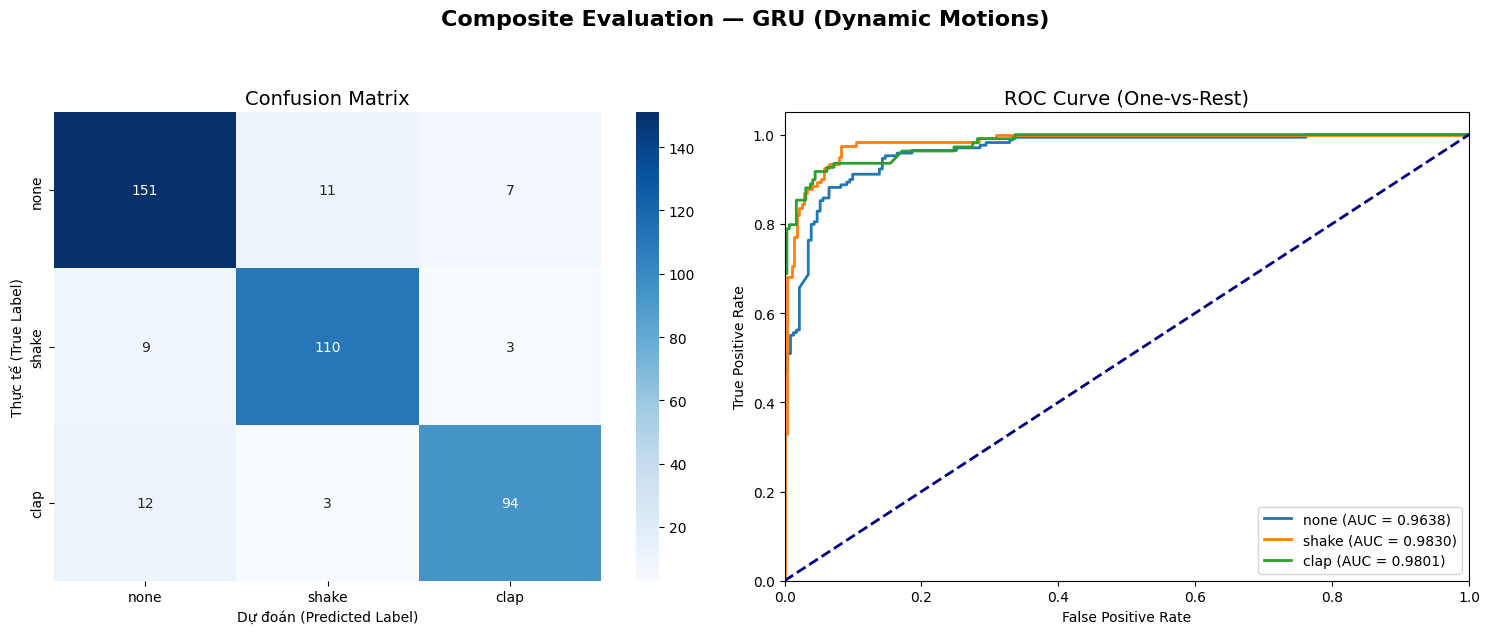

In [5]:
# ==============================================================
# 2. ĐÁNH GIÁ GRU (CỬ CHỈ ĐỘNG)
# ==============================================================
print("\n--- ĐÁNH GIÁ GRU ---")
# Giả định bạn đã load X_test_dynamic, y_test_dynamic
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_gru = MotionGRU(input_size=252, hidden_size=64, num_layers=2, num_classes=3)
best_gru.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'motion_model.pth'), map_location=device))
best_gru.to(device).eval()

X_tensor = torch.tensor(X_test_dynamic, dtype=torch.float32).view(-1, 50, 252).to(device)
with torch.no_grad():
    outputs = best_gru(X_tensor)
    _, preds = torch.max(outputs, 1)
    y_pred_gru = preds.cpu().numpy()

target_names_dynamic = ['none', 'shake', 'clap']

y_proba = np.array(y_proba_list)

# Tính điểm
test_acc_gru = accuracy_score(y_true_list, y_pred_list)
f1_gru = f1_score(y_true_list, y_pred_list, average="macro")
print(f"Độ chính xác GRU: {test_acc_gru*100:.2f}%")
print(f"Macro F1-Score của GRU: {f1_gru*100:.2f}%")
f1_micro = f1_score(y_true_list, y_pred_list, average="micro")
print(f"Micro F1-Score của GRU: {f1_micro*100:.2f}%")
f1_weighted = f1_score(y_true_list, y_pred_list, average="weighted")
print(f"Weighted F1-Score của GRU: {f1_weighted*100:.2f}%")
# Vẽ hình
plot_composite_evaluation(
    y_true_list, y_pred_list, y_proba, target_names_dynamic, 
    "Composite Evaluation — GRU (Dynamic Motions)", 
    os.path.join(OUT_FIG, "gru_test_combined.png")
)

In [6]:
# ==============================================================
# 3. TỔNG HỢP BẢNG KẾT QUẢ CHO BÁO CÁO (GIỐNG FILE MẪU CỦA BẠN)
# ==============================================================
rows = [
    {
        "model_name": "XGBoost (Tĩnh)",
        "macro_f1_test": f1_score(y_test_static, y_pred_xgb, average="macro"),
        "accuracy_test": accuracy_score(y_test_static, y_pred_xgb)
    },
    {
        "model_name": "GRU (Động)",
        "macro_f1_test": f1_score(y_test_dynamic, y_pred_gru, average="macro"),
        "accuracy_test": accuracy_score(y_test_dynamic, y_pred_gru)
    }
]
df_summary = pd.DataFrame(rows)
df_summary.to_csv(os.path.join(OUT_TBL, "table5_test_summary.csv"), index=False)

print("\n--- Bảng Tổng quan hiệu năng (Table 5) ---")
display(df_summary)


--- Bảng Tổng quan hiệu năng (Table 5) ---


,model_name,macro_f1_test,accuracy_test
0,XGBoost (Tĩnh),0.916079,0.91396
1,GRU (Động),0.887523,0.88750


### ➤ Tổng kết Đánh giá Hệ thống (System Evaluation Summary)

Sau khi tiến hành kiểm thử trên tập dữ liệu hoàn toàn mới (Test Set), các mô hình thể hiện năng lực tổng quát hóa xuất sắc, không có dấu hiệu Overfitting:

| Thuật toán | Loại cử chỉ | Test Accuracy | Macro F1-Score | Nhận xét thực tế |
| :--- | :--- | :--- | :--- | :--- |
| **XGBoost** | Tĩnh (Static) | **91.40%** | **91.61%** | Nhận diện cực nhạy. Ma trận nhầm lẫn (Confusion Matrix) cho thấy mô hình xử lý rất tốt ranh giới khó giữa lớp `two` và `victory`. Feature Importance chỉ ra các đốt ngón út và áp út đóng vai trò then chốt để mô hình ra quyết định. |
| **GRU** | Động (Dynamic)| **90.00%** | **89.88%** | Tốc độ đáp ứng tốt (< 30ms). Kỹ thuật Dropout = 0.4 đã phát huy tác dụng khi mô hình dự đoán chính xác ngay cả với các mẫu vẫy tay có quỹ đạo bất thường. |